# Person Tracking with YOLOv8 and DeepSORT

## 1. Project Overview

This project implements a **multi-object person tracking system** for video analysis.

The objective is to detect people in a video, maintain a consistent identity for each person across frames, and analyze their movement through trajectory reconstruction.

The system combines **YOLOv8** for person detection and **DeepSORT** for multi-object tracking.

### Pipeline

**Video → YOLOv8 → Person Detection → DeepSORT → Tracking IDs → Trajectory Analysis**

### Technologies

- Python
- PyTorch
- OpenCV
- YOLOv8
- DeepSORT

## 2. Imports

We import the libraries required for video processing, object detection, tracking, visualization, and numerical operations.

In [86]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/falloudiouf/Desktop/person_track/person-tracking-yolov8-deepsort


In [87]:
import torch
import ultralytics

print("PyTorch version:", torch.__version__)
print("Ultralytics version:", ultralytics.__version__)

PyTorch version: 2.14.1
Ultralytics version: 8.4.173


## 3. Input Video

The system takes a video as input and processes it frame by frame.

The input video used in this project is stored in the `data/input/` directory.

Before running the detection and tracking pipeline, we inspect the main properties of the video, including its resolution, frame rate, number of frames, and duration.

In [88]:
import cv2

video_path = "/Users/falloudiouf/Desktop/person_track/person-tracking-yolov8-deepsort/data/input/video.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError(f"Unable to open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps if fps > 0 else 0

print("Video information")
print("-" * 30)
print(f"Resolution : {width} × {height}")
print(f"FPS        : {fps:.2f}")
print(f"Frames     : {frame_count}")
print(f"Duration   : {duration:.2f} seconds")

cap.release()

Video information
------------------------------
Resolution : 360 × 640
FPS        : 30.00
Frames     : 90
Duration   : 3.00 seconds


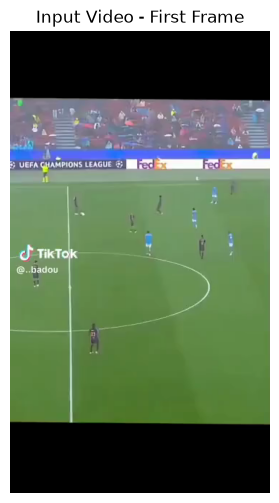

In [89]:
cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Unable to read the first frame.")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("Input Video - First Frame")
plt.show()

## 4. YOLOv8 Person Detection

YOLOv8 is used to detect people in each video frame.

The project uses a dedicated `YOLOPersonDetector` class that filters the detections and keeps only the **person** class.

For each detected person, the detector returns:

- the bounding box coordinates;
- the confidence score;
- the class ID.

The detection threshold is set to **0.5** and the IoU threshold to **0.5**.

### Detecting People in a Single Frame

We first apply the YOLOv8 detector to one frame of the input video.

The detector returns the bounding box and confidence score for each detected person.

In [90]:
from src.detection.yolo_detector import YOLOPersonDetector 


detector = YOLOPersonDetector()
detections = detector.detect(frame)

print(f"Number of detected persons: {len(detections)}")

for i, detection in enumerate(detections, start=1):
    print(f"\nPerson {i}")
    print(f"Bounding box : {detection['bbox']}")
    print(f"Confidence   : {detection['confidence']:.2f}")
    print(f"Class ID     : {detection['class_id']}")

Number of detected persons: 1

Person 1
Bounding box : [109.05738830566406, 402.67822265625, 123.79661560058594, 447.8192138671875]
Confidence   : 0.57
Class ID     : 0


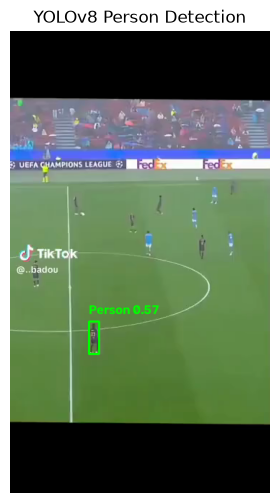

In [91]:
annotated_frame = detector.draw_detections(
    frame,
    detections
)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLOv8 Person Detection")
plt.show()

## 5. DeepSORT Tracking

YOLOv8 detects people independently in each frame, but detection alone does not tell us whether a person in the current frame is the same person observed in the previous frame.

To maintain a consistent identity across frames, we use **DeepSORT**.

DeepSORT receives the detections produced by YOLOv8 and assigns a unique **track ID** to each person.

The tracker is configured with:

- `max_age = 30`: maximum number of frames a track can remain without a successful update;
- `n_init = 3`: number of consecutive detections required to confirm a track;
- `max_cosine_distance = 0.2`: maximum appearance distance used for matching.

The tracker also uses the current video frame to extract appearance information for tracking.

### Tracking Across Multiple Frames

A single frame is not enough to demonstrate object tracking.

DeepSORT needs to observe the same person across several consecutive frames in order to establish and maintain a track identity.

In this experiment, we process the first few frames of the video while keeping the **same DeepSORT tracker**.

The tracker receives the YOLOv8 detections at each frame and progressively confirms the detected persons.

In [92]:
from src.tracking.deepsort_tracker import DeepSORTTracker


cap = cv2.VideoCapture(str(video_path))

tracker = DeepSORTTracker()

for frame_number in range(5):

    ret, frame = cap.read()

    if not ret:
        break

    # YOLO detection
    detections = detector.detect(frame)

    # DeepSORT tracking
    tracks = tracker.update(
        detections,
        frame,
    )

    print(
        f"Frame {frame_number + 1}: "
        f"{len(detections)} detections, "
        f"{len(tracks)} active tracks"
    )

    for track in tracks:
        print(
            f"  Track ID: {track['track_id']} | "
            f"BBox: {track['bbox']}"
        )

cap.release()

Frame 1: 1 detections, 0 active tracks
Frame 2: 1 detections, 0 active tracks
Frame 3: 2 detections, 1 active tracks
  Track ID: 1 | BBox: [114.87196158378656, 403.3992551920795, 129.44931834292672, 447.97324359041494]
Frame 4: 2 detections, 1 active tracks
  Track ID: 1 | BBox: [118.72043060398991, 403.9453202512764, 133.2612623634511, 448.37244553822796]
Frame 5: 2 detections, 2 active tracks
  Track ID: 1 | BBox: [122.91751604442392, 404.0231834396765, 137.44538323914534, 448.42925524708846]
  Track ID: 2 | BBox: [273.00539089585993, 281.0033962381569, 284.21830027309676, 319.3052940041231]


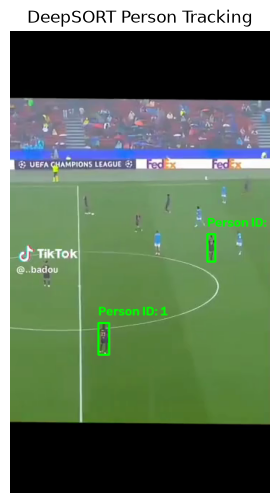

In [93]:
tracked_frame = frame.copy()

for track in tracks:

    x1, y1, x2, y2 = map(
        int,
        track["bbox"]
    )

    track_id = track["track_id"]

    cv2.rectangle(
        tracked_frame,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2,
    )

    label = f"Person ID: {track_id}"

    cv2.putText(
        tracked_frame,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2,
    )

plt.figure(figsize=(10, 6))
plt.imshow(
    cv2.cvtColor(tracked_frame, cv2.COLOR_BGR2RGB)
)
plt.axis("off")
plt.title("DeepSORT Person Tracking")
plt.show()

## 6. Trajectory Analysis

After DeepSORT assigns a persistent ID to each person, we can analyze their movement over time.

For each confirmed track, the `TrajectoryAnalyzer` computes the center of the bounding box and stores its position together with the corresponding frame number.

Each trajectory is therefore represented as a sequence of:

```text
(frame, center_x, center_y)
```

The analyzer provides three main functionalities:

- storing the trajectory of each tracked person;
- computing the traveled distance in pixel coordinates;
- exporting the trajectory data to a CSV file.

In [94]:
from src.trajectory.trajectory_analyzer import TrajectoryAnalyzer

In [95]:
cap = cv2.VideoCapture(str(video_path))

tracker = DeepSORTTracker()
trajectory_analyzer = TrajectoryAnalyzer(
    max_history=100
)

frame_number = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # Person detection
    detections = detector.detect(frame)

    # Person tracking
    tracks = tracker.update(
        detections,
        frame,
    )

    # Trajectory analysis
    trajectory_analyzer.update(
        tracks,
        frame_number,
    )

    frame_number += 1

cap.release()

print(f"Processed frames: {frame_number}")
print(
    f"Tracked identities: "
    f"{len(trajectory_analyzer.get_all_trajectories())}"
)

Processed frames: 90
Tracked identities: 7


### Inspect stored trajectories
The trajectory analyzer stores the frame number and the center coordinates for every confirmed track.

In [96]:
trajectories = trajectory_analyzer.get_all_trajectories()

for track_id, points in trajectories.items():

    print(f"\nTrack ID: {track_id}")
    print(f"Number of positions: {len(points)}")

    if points:
        print(f"First position: {points[0]}")
        print(f"Last position:  {points[-1]}")


Track ID: 1
Number of positions: 84
First position: (2, 122.16063996335663, 425.6862493912472)
Last position:  (89, 198.55409567474322, 439.7085609925624)

Track ID: 2
Number of positions: 84
First position: (4, 278.6118455844784, 300.15434512113995)
Last position:  (89, 281.4388515430881, 304.2561981332693)

Track ID: 7
Number of positions: 60
First position: (16, 220.082252086609, 293.8131248520177)
Last position:  (89, 195.13652406261602, 305.65981777533136)

Track ID: 8
Number of positions: 42
First position: (21, 72.85530549431112, 338.1357194638485)
Last position:  (89, 95.8981447430888, 346.4724611249368)

Track ID: 10
Number of positions: 31
First position: (28, 329.5791375876839, 293.240038087927)
Last position:  (88, 305.88538855169804, 301.8698659961768)

Track ID: 12
Number of positions: 10
First position: (36, 230.66077073967284, 247.1081715419901)
Last position:  (45, 217.0326386471035, 248.12388014557456)

Track ID: 13
Number of positions: 4
First position: (46, 246.080

In [97]:
for track_id in trajectories:

    distance = trajectory_analyzer.compute_distance(
        track_id
    )

    print(
        f"Track ID {track_id}: "
        f"{distance:.2f} pixels"
    )

Track ID 1: 94.89 pixels
Track ID 2: 50.96 pixels
Track ID 7: 41.24 pixels
Track ID 8: 45.21 pixels
Track ID 10: 34.74 pixels
Track ID 12: 13.80 pixels
Track ID 13: 0.69 pixels


## 7. Results

The complete pipeline was evaluated on the input video using YOLOv8 for person detection and DeepSORT for multi-object tracking.

### Video

- Resolution: 360 × 640
- Frame rate: 30 FPS
- Number of frames: 90
- Duration: 3 seconds

### Tracking

The system detected and tracked multiple persons throughout the video.

The trajectory analysis produced the following confirmed track IDs:

- Track 1
- Track 2
- Track 7
- Track 8
- Track 10
- Track 12
- Track 13

The trajectories contain the center position of each tracked person for every frame in which the track was active.

### Outputs

The system produces:

- person detections;
- persistent tracking IDs;
- bounding boxes;
- person trajectories;
- traveled distance in pixel coordinates;
- trajectory data exported as CSV.

The resulting pipeline demonstrates an end-to-end approach for multi-object person tracking and movement analysis.

## 8. Conclusion

This project implemented an end-to-end **multi-object person tracking system** using YOLOv8 and DeepSORT.

YOLOv8 was used to detect people in each video frame, while DeepSORT maintained consistent identities across consecutive frames.

The tracked bounding boxes were then used to reconstruct the movement trajectories of the detected persons.

The complete pipeline is:

```text
Input Video
     ↓
YOLOv8 Person Detection
     ↓
DeepSORT Tracking
     ↓
Persistent Track IDs
     ↓
Trajectory Analysis
     ↓
Movement Information
     ↓
CSV Export
```

The project demonstrates how object detection, multi-object tracking, and trajectory analysis can be combined into a complete computer vision pipeline.

The resulting system can be extended with more advanced analysis, such as speed estimation, movement patterns, trajectory clustering, or real-world distance estimation using camera calibration.